In [36]:
import pandas as pd
import optuna
import shap

import matplotlib.pyplot as plt
import utils.optuna_utils as optuna_utils
import utils.pca_utils as pca_utils
import utils.json_utils as json_utils

from utils.shapley_utils import Result
from pathlib import Path
from configuration.configuration import load_config
from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score, mean_squared_error

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

<h1>Wczytywanie konfiguracji i danych<h1>

In [2]:
path = Path()

In [3]:
config = load_config(path / 'configuration' / 'config.json')
xgb_hiperparameters_path = path / 'configuration' / 'xgb_hiperparameters.json'
df = pd.read_csv(path / 'data' / 'prepared_dataset.csv')

In [4]:
features = config.features_names
target = config.prediction_column
categories_names = config.prediction_categories
df

,id,intelligence,strength,speed,durability,power,combat,publisher,alignment,gender,height,weight,eye-color,hair-color
0,1,38.0,100.0,17.0,80.0,24.0,64.0,32.0,2.0,2.0,203.0,441.0,19.0,15.0
1,2,88.0,28.0,35.0,65.0,100.0,85.0,16.0,2.0,2.0,191.0,65.0,3.0,15.0
2,3,50.0,90.0,53.0,64.0,99.0,65.0,15.0,2.0,2.0,185.0,90.0,3.0,15.0
3,4,63.0,80.0,53.0,90.0,62.0,95.0,32.0,1.0,2.0,203.0,441.0,8.0,15.0
4,5,88.0,63.0,83.0,100.0,100.0,55.0,32.0,1.0,2.0,0.0,0.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,726,88.0,10.0,12.0,28.0,12.0,14.0,3.0,2.0,2.0,183.0,83.0,3.0,4.0
556,727,50.0,10.0,35.0,28.0,31.0,28.0,32.0,2.0,1.0,165.0,52.0,3.0,24.0
557,729,88.0,52.0,33.0,25.0,100.0,90.0,21.0,2.0,2.0,66.0,17.0,6.0,25.0
558,730,81.0,10.0,23.0,28.0,100.0,56.0,15.0,2.0,1.0,170.0,57.0,3.0,2.0


In [5]:
X = df[features]
Y = df[[target]]

<h1>Oversampling i SMOTE</h1>

Sprawdźmy czy mamy zrównoważoną ilość danych dla każdej kategorii. Jeżeli nie to model nie zostanie poprawnie nauczony i będzie faworyzował dominującą kategorię.

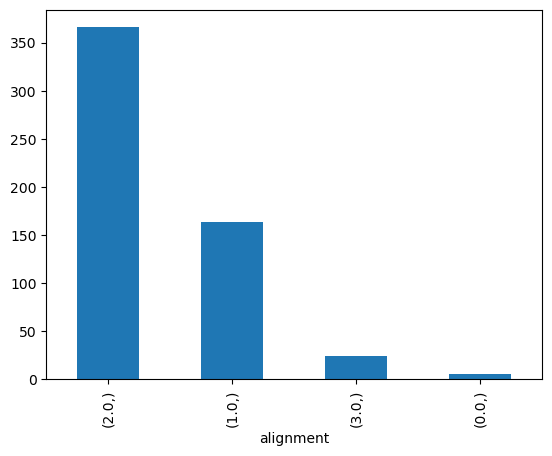

In [6]:
Y.value_counts().plot.bar();

Jak widać zbiór nie jest zbalansowany co najprawdopodobniej spowoduje problemy. Uzupełnijmy dane danymi syntetycznymi wygenerowanymi przy pomocy metody SMOTE

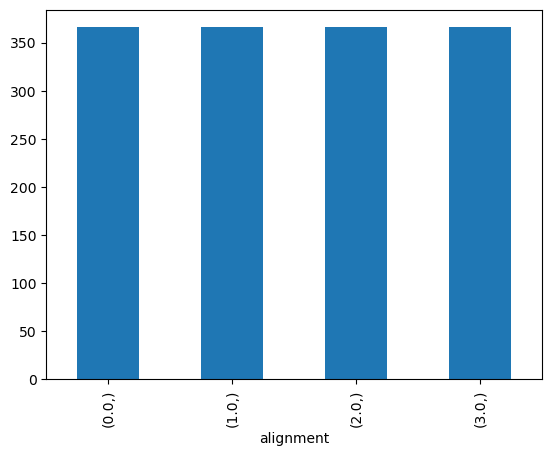

In [7]:
smote = SMOTE(random_state=config.smote_random_state)
X_smote, Y_smote = smote.fit_resample(X, Y)
Y_smote.value_counts().plot.bar();

Jak widac powyżej nasz zbiór jest teraz zbalansowany

<h1>Przygotowanie zbioru uczącego i testowegp</h1>

Podzielmy dataset na dwa zbiory: 80% danych utworzy zbiór uczący a 20% testowy

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_smote, Y_smote, test_size=0.2, random_state=config.data_split_random_state)

<h1>PCA</h1>

Wiemy z analizy że mamy dwiepary skorelowanych danych. Skorelowane ze sobą są kolumny <u>weight</u> i <u>height</u> oraz <u>strength</u> i <u>durability</u>. Sprobójmy z tych 4 kolumn utworzyć 2 za pomocą metody PCA

In [9]:
columns_to_pca = ['weight', 'height', 'strength', 'durability']

Zanim jednak wykonamy na danych metode PCA musimy te dane zserializować. W tym przypadku użyłem StandardScalera

In [10]:
X_train = pca_utils.scale(X_train, columns_to_pca)
X_test = pca_utils.scale(X_test, columns_to_pca)

Teraz możemy zaaplikować PCA dla wybranych kolumn

In [11]:
X_train = pca_utils.replace_by_pca(X_train, 2, columns_to_pca)
X_test = pca_utils.replace_by_pca(X_test, 2, columns_to_pca)

0.8264447508973465
0.833166812574763


<h1>Uczenie modelu</h1>

In [12]:
model = XGBClassifier()
model.fit(X_train, y_train)
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)


In [13]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))
print(f'MSE: {mse}')

Accuracy: 85.67%
MSE: 0.26621160409556316


In [14]:
pd.crosstab(y_test[target].tolist(), y_pred, rownames=['true'], colnames=['predicted'])

predicted,0,1,2,3
true,,,,
0.0,68,0,0,0
1.0,0,65,20,3
2.0,1,13,55,2
3.0,3,0,0,63


Widać że na zbiorze testowym uzyskaliśmy 85,67% prawidłowych klasyfikacji. Nie jest żle ale może uda się dostroić model?

<h1>Optuna</h1>

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(optuna_utils.get_objective(X_train, X_test, y_train, y_test), n_trials=200,show_progress_bar=True)
study.best_trial

[I 2024-12-03 15:05:52,680] A new study created in memory with name: no-name-9818bcb0-93f5-4764-a67e-09ed43f98e13
Best trial: 0. Best value: 0.662116:   0%|          | 1/200 [00:12<40:12, 12.12s/it]

[I 2024-12-03 15:06:04,803] Trial 0 finished with value: 0.6621160409556314 and parameters: {'n_estimators': 262, 'learning_rate': 0.0013403351679625198, 'max_depth': 10, 'subsample': 0.8054018157341001, 'colsample_bytree': 0.08489280555699819, 'min_child_weight': 12}. Best is trial 0 with value: 0.6621160409556314.


Best trial: 0. Best value: 0.662116:   1%|          | 2/200 [00:17<26:08,  7.92s/it]

[I 2024-12-03 15:06:09,788] Trial 1 finished with value: 0.6348122866894198 and parameters: {'n_estimators': 261, 'learning_rate': 0.023788227791534822, 'max_depth': 5, 'subsample': 0.06467075943704959, 'colsample_bytree': 0.25672223446257963, 'min_child_weight': 6}. Best is trial 0 with value: 0.6621160409556314.


Best trial: 2. Best value: 0.703072:   2%|▏         | 3/200 [00:35<41:13, 12.55s/it]

[I 2024-12-03 15:06:27,854] Trial 2 finished with value: 0.7030716723549488 and parameters: {'n_estimators': 858, 'learning_rate': 0.016991540348516118, 'max_depth': 5, 'subsample': 0.26926974348358285, 'colsample_bytree': 0.19194826638837242, 'min_child_weight': 17}. Best is trial 2 with value: 0.7030716723549488.


Best trial: 3. Best value: 0.774744:   2%|▏         | 4/200 [01:32<1:38:54, 30.28s/it]

[I 2024-12-03 15:07:25,304] Trial 3 finished with value: 0.7747440273037542 and parameters: {'n_estimators': 913, 'learning_rate': 0.0037947383425587047, 'max_depth': 10, 'subsample': 0.8504588677637991, 'colsample_bytree': 0.4927856489336122, 'min_child_weight': 20}. Best is trial 3 with value: 0.7747440273037542.


Best trial: 4. Best value: 0.812287:   2%|▎         | 5/200 [01:43<1:15:32, 23.24s/it]

[I 2024-12-03 15:07:36,077] Trial 4 finished with value: 0.8122866894197952 and parameters: {'n_estimators': 233, 'learning_rate': 0.042686874229008416, 'max_depth': 7, 'subsample': 0.7383767872451451, 'colsample_bytree': 0.4057113051004566, 'min_child_weight': 13}. Best is trial 4 with value: 0.8122866894197952.


Best trial: 4. Best value: 0.812287:   3%|▎         | 6/200 [01:59<1:07:38, 20.92s/it]

[I 2024-12-03 15:07:52,490] Trial 5 finished with value: 0.24232081911262798 and parameters: {'n_estimators': 991, 'learning_rate': 0.0019132318786648668, 'max_depth': 3, 'subsample': 0.05599022163567434, 'colsample_bytree': 0.530817754222418, 'min_child_weight': 20}. Best is trial 4 with value: 0.8122866894197952.


Best trial: 4. Best value: 0.812287:   4%|▎         | 7/200 [02:03<49:01, 15.24s/it]  

[I 2024-12-03 15:07:56,033] Trial 6 finished with value: 0.6689419795221843 and parameters: {'n_estimators': 408, 'learning_rate': 0.02581791240122418, 'max_depth': 1, 'subsample': 0.833280809763971, 'colsample_bytree': 0.8492227884278655, 'min_child_weight': 15}. Best is trial 4 with value: 0.8122866894197952.


Best trial: 4. Best value: 0.812287:   4%|▍         | 8/200 [02:16<46:47, 14.62s/it]

[I 2024-12-03 15:08:09,326] Trial 7 finished with value: 0.7201365187713311 and parameters: {'n_estimators': 336, 'learning_rate': 0.004971874412306704, 'max_depth': 7, 'subsample': 0.5410166932178249, 'colsample_bytree': 0.5982096133067655, 'min_child_weight': 19}. Best is trial 4 with value: 0.8122866894197952.


Best trial: 4. Best value: 0.812287:   4%|▍         | 9/200 [02:55<1:10:15, 22.07s/it]

[I 2024-12-03 15:08:47,776] Trial 8 finished with value: 0.764505119453925 and parameters: {'n_estimators': 975, 'learning_rate': 0.006216061290169036, 'max_depth': 7, 'subsample': 0.3818758758293574, 'colsample_bytree': 0.8641587017207966, 'min_child_weight': 13}. Best is trial 4 with value: 0.8122866894197952.


Best trial: 4. Best value: 0.812287:   5%|▌         | 10/200 [03:42<1:34:33, 29.86s/it]

[I 2024-12-03 15:09:35,085] Trial 9 finished with value: 0.7986348122866894 and parameters: {'n_estimators': 869, 'learning_rate': 0.003098636038217898, 'max_depth': 8, 'subsample': 0.47843862093858, 'colsample_bytree': 0.4745685936443031, 'min_child_weight': 6}. Best is trial 4 with value: 0.8122866894197952.


Best trial: 10. Best value: 0.8157:   6%|▌         | 11/200 [03:45<1:08:43, 21.82s/it] 

[I 2024-12-03 15:09:38,657] Trial 10 finished with value: 0.8156996587030717 and parameters: {'n_estimators': 114, 'learning_rate': 0.09973405110223904, 'max_depth': 3, 'subsample': 0.9910069619180097, 'colsample_bytree': 0.31491282882216737, 'min_child_weight': 2}. Best is trial 10 with value: 0.8156996587030717.


Best trial: 11. Best value: 0.819113:   6%|▌         | 12/200 [03:49<51:21, 16.39s/it]  

[I 2024-12-03 15:09:42,635] Trial 11 finished with value: 0.8191126279863481 and parameters: {'n_estimators': 137, 'learning_rate': 0.09198178214389871, 'max_depth': 3, 'subsample': 0.9740561015849025, 'colsample_bytree': 0.32709069199933877, 'min_child_weight': 1}. Best is trial 11 with value: 0.8191126279863481.


Best trial: 11. Best value: 0.819113:   6%|▋         | 13/200 [03:52<38:20, 12.30s/it]

[I 2024-12-03 15:09:45,530] Trial 12 finished with value: 0.8054607508532423 and parameters: {'n_estimators': 148, 'learning_rate': 0.09987091057277336, 'max_depth': 3, 'subsample': 0.9843960957702781, 'colsample_bytree': 0.26444025850440045, 'min_child_weight': 1}. Best is trial 11 with value: 0.8191126279863481.


Best trial: 13. Best value: 0.843003:   7%|▋         | 14/200 [04:04<37:18, 12.04s/it]

[I 2024-12-03 15:09:56,952] Trial 13 finished with value: 0.8430034129692833 and parameters: {'n_estimators': 550, 'learning_rate': 0.09043477128796756, 'max_depth': 2, 'subsample': 0.9969114222382535, 'colsample_bytree': 0.6714117910239898, 'min_child_weight': 1}. Best is trial 13 with value: 0.8430034129692833.


Best trial: 13. Best value: 0.843003:   8%|▊         | 15/200 [04:15<36:31, 11.84s/it]

[I 2024-12-03 15:10:08,354] Trial 14 finished with value: 0.7440273037542662 and parameters: {'n_estimators': 634, 'learning_rate': 0.05512637322189086, 'max_depth': 1, 'subsample': 0.6573169689125535, 'colsample_bytree': 0.6951266153137245, 'min_child_weight': 5}. Best is trial 13 with value: 0.8430034129692833.


Best trial: 13. Best value: 0.843003:   8%|▊         | 16/200 [04:25<34:17, 11.18s/it]

[I 2024-12-03 15:10:17,992] Trial 15 finished with value: 0.7406143344709898 and parameters: {'n_estimators': 582, 'learning_rate': 0.011011240912406892, 'max_depth': 2, 'subsample': 0.9226157860065456, 'colsample_bytree': 0.679487762034463, 'min_child_weight': 9}. Best is trial 13 with value: 0.8430034129692833.


Best trial: 13. Best value: 0.843003:   8%|▊         | 17/200 [04:44<41:44, 13.69s/it]

[I 2024-12-03 15:10:37,506] Trial 16 finished with value: 0.8430034129692833 and parameters: {'n_estimators': 708, 'learning_rate': 0.04457547882143859, 'max_depth': 4, 'subsample': 0.6856941483172038, 'colsample_bytree': 0.9716716987318641, 'min_child_weight': 3}. Best is trial 13 with value: 0.8430034129692833.


Best trial: 13. Best value: 0.843003:   9%|▉         | 18/200 [05:04<47:24, 15.63s/it]

[I 2024-12-03 15:10:57,657] Trial 17 finished with value: 0.8225255972696246 and parameters: {'n_estimators': 735, 'learning_rate': 0.05283794855781285, 'max_depth': 4, 'subsample': 0.6173403509848953, 'colsample_bytree': 0.9505272040228062, 'min_child_weight': 4}. Best is trial 13 with value: 0.8430034129692833.


Best trial: 13. Best value: 0.843003:  10%|▉         | 19/200 [05:17<44:21, 14.70s/it]

[I 2024-12-03 15:11:10,203] Trial 18 finished with value: 0.8122866894197952 and parameters: {'n_estimators': 495, 'learning_rate': 0.033115351581244186, 'max_depth': 4, 'subsample': 0.7130377469517164, 'colsample_bytree': 0.9855671466452149, 'min_child_weight': 9}. Best is trial 13 with value: 0.8430034129692833.


Best trial: 13. Best value: 0.843003:  10%|█         | 20/200 [05:26<39:21, 13.12s/it]

[I 2024-12-03 15:11:19,640] Trial 19 finished with value: 0.7610921501706485 and parameters: {'n_estimators': 743, 'learning_rate': 0.013612437066012166, 'max_depth': 2, 'subsample': 0.2711014752739925, 'colsample_bytree': 0.7510774301510657, 'min_child_weight': 3}. Best is trial 13 with value: 0.8430034129692833.


Best trial: 13. Best value: 0.843003:  10%|█         | 21/200 [05:45<43:52, 14.71s/it]

[I 2024-12-03 15:11:38,036] Trial 20 finished with value: 0.8225255972696246 and parameters: {'n_estimators': 713, 'learning_rate': 0.06352646960270456, 'max_depth': 6, 'subsample': 0.5519563973437709, 'colsample_bytree': 0.8232215932889678, 'min_child_weight': 8}. Best is trial 13 with value: 0.8430034129692833.


Best trial: 13. Best value: 0.843003:  11%|█         | 22/200 [06:11<54:07, 18.25s/it]

[I 2024-12-03 15:12:04,543] Trial 21 finished with value: 0.8361774744027304 and parameters: {'n_estimators': 737, 'learning_rate': 0.05590697633809328, 'max_depth': 4, 'subsample': 0.6320316197475273, 'colsample_bytree': 0.9864761315397881, 'min_child_weight': 4}. Best is trial 13 with value: 0.8430034129692833.


Best trial: 13. Best value: 0.843003:  12%|█▏        | 23/200 [06:20<44:53, 15.22s/it]

[I 2024-12-03 15:12:12,689] Trial 22 finished with value: 0.7918088737201365 and parameters: {'n_estimators': 505, 'learning_rate': 0.03498590405462646, 'max_depth': 2, 'subsample': 0.4158625747317693, 'colsample_bytree': 0.9222862514510212, 'min_child_weight': 3}. Best is trial 13 with value: 0.8430034129692833.


Best trial: 13. Best value: 0.843003:  12%|█▏        | 24/200 [06:34<43:58, 14.99s/it]

[I 2024-12-03 15:12:27,150] Trial 23 finished with value: 0.8361774744027304 and parameters: {'n_estimators': 657, 'learning_rate': 0.06430559573393839, 'max_depth': 4, 'subsample': 0.6291856994301005, 'colsample_bytree': 0.9977229499800716, 'min_child_weight': 6}. Best is trial 13 with value: 0.8430034129692833.


Best trial: 24. Best value: 0.846416:  12%|█▎        | 25/200 [07:00<53:35, 18.38s/it]

[I 2024-12-03 15:12:53,426] Trial 24 finished with value: 0.8464163822525598 and parameters: {'n_estimators': 809, 'learning_rate': 0.020779432060949544, 'max_depth': 5, 'subsample': 0.7741773120241763, 'colsample_bytree': 0.7861229723427196, 'min_child_weight': 4}. Best is trial 24 with value: 0.8464163822525598.


Best trial: 52. Best value: 0.880546:  44%|████▎     | 87/200 [3:21:17<26:25:24, 841.81s/it] 

[I 2024-12-03 18:27:09,837] Trial 86 finished with value: 0.863481228668942 and parameters: {'n_estimators': 862, 'learning_rate': 0.017794473126008535, 'max_depth': 6, 'subsample': 0.7764830666648558, 'colsample_bytree': 0.9149430879024177, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  44%|████▍     | 88/200 [3:21:54<18:40:45, 600.40s/it]

[I 2024-12-03 18:27:46,963] Trial 87 finished with value: 0.856655290102389 and parameters: {'n_estimators': 678, 'learning_rate': 0.025146255439207444, 'max_depth': 8, 'subsample': 0.7997503747114281, 'colsample_bytree': 0.8517984024565854, 'min_child_weight': 4}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  44%|████▍     | 89/200 [3:22:37<13:21:28, 433.23s/it]

[I 2024-12-03 18:28:30,135] Trial 88 finished with value: 0.8498293515358362 and parameters: {'n_estimators': 898, 'learning_rate': 0.038852115798469596, 'max_depth': 9, 'subsample': 0.8512504471410962, 'colsample_bytree': 0.7999356213746217, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  45%|████▌     | 90/200 [3:23:28<9:44:09, 318.63s/it] 

[I 2024-12-03 18:29:21,354] Trial 89 finished with value: 0.8395904436860068 and parameters: {'n_estimators': 745, 'learning_rate': 0.015239710468650587, 'max_depth': 8, 'subsample': 0.3542926149596746, 'colsample_bytree': 0.899837300610925, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  46%|████▌     | 91/200 [3:24:19<7:13:06, 238.41s/it]

[I 2024-12-03 18:30:12,582] Trial 90 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 927, 'learning_rate': 0.02040460070375626, 'max_depth': 7, 'subsample': 0.7474104981687194, 'colsample_bytree': 0.832145277639825, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  46%|████▌     | 92/200 [3:25:13<5:29:28, 183.04s/it]

[I 2024-12-03 18:31:06,443] Trial 91 finished with value: 0.8771331058020477 and parameters: {'n_estimators': 970, 'learning_rate': 0.021230253521237828, 'max_depth': 7, 'subsample': 0.7340423729671783, 'colsample_bytree': 0.8699338691545339, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  46%|████▋     | 93/200 [3:26:36<4:32:48, 152.98s/it]

[I 2024-12-03 18:32:29,261] Trial 92 finished with value: 0.8600682593856656 and parameters: {'n_estimators': 968, 'learning_rate': 0.02039390761056052, 'max_depth': 6, 'subsample': 0.7563868508725463, 'colsample_bytree': 0.831034503856983, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  47%|████▋     | 94/200 [3:29:07<4:29:17, 152.42s/it]

[I 2024-12-03 18:35:00,398] Trial 93 finished with value: 0.8600682593856656 and parameters: {'n_estimators': 931, 'learning_rate': 0.023736582909541715, 'max_depth': 7, 'subsample': 0.6942818017841594, 'colsample_bytree': 0.7623874910817017, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  48%|████▊     | 95/200 [3:29:56<3:32:14, 121.28s/it]

[I 2024-12-03 18:35:49,004] Trial 94 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 977, 'learning_rate': 0.02853633466632594, 'max_depth': 7, 'subsample': 0.6356476460009217, 'colsample_bytree': 0.8617843323579034, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  48%|████▊     | 96/200 [3:30:40<2:50:17, 98.25s/it] 

[I 2024-12-03 18:36:33,518] Trial 95 finished with value: 0.856655290102389 and parameters: {'n_estimators': 818, 'learning_rate': 0.01318314537842199, 'max_depth': 6, 'subsample': 0.7112476588137155, 'colsample_bytree': 0.9319712137485845, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  48%|████▊     | 97/200 [3:31:43<2:30:15, 87.53s/it]

[I 2024-12-03 18:37:36,044] Trial 96 finished with value: 0.8532423208191127 and parameters: {'n_estimators': 955, 'learning_rate': 0.016633212838463945, 'max_depth': 7, 'subsample': 0.6747166742823034, 'colsample_bytree': 0.7179208354316743, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  49%|████▉     | 98/200 [3:32:32<2:09:22, 76.10s/it]

[I 2024-12-03 18:38:25,472] Trial 97 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 902, 'learning_rate': 0.02133693453617808, 'max_depth': 7, 'subsample': 0.8086367994437125, 'colsample_bytree': 0.8364094518326969, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  50%|████▉     | 99/200 [3:32:53<1:40:17, 59.58s/it]

[I 2024-12-03 18:38:46,513] Trial 98 finished with value: 0.8088737201365188 and parameters: {'n_estimators': 371, 'learning_rate': 0.025473811260396502, 'max_depth': 6, 'subsample': 0.6045760226272148, 'colsample_bytree': 0.8773080221058048, 'min_child_weight': 9}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  50%|█████     | 100/200 [3:34:19<1:52:23, 67.44s/it]

[I 2024-12-03 18:40:12,278] Trial 99 finished with value: 0.8532423208191127 and parameters: {'n_estimators': 914, 'learning_rate': 0.0186920943344086, 'max_depth': 7, 'subsample': 0.8331932703773152, 'colsample_bytree': 0.3376237589868872, 'min_child_weight': 4}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  50%|█████     | 101/200 [3:35:13<1:44:25, 63.28s/it]

[I 2024-12-03 18:41:05,868] Trial 100 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 791, 'learning_rate': 0.022582858874224336, 'max_depth': 7, 'subsample': 0.743085048835261, 'colsample_bytree': 0.8414576701231585, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  51%|█████     | 102/200 [3:35:58<1:34:20, 57.76s/it]

[I 2024-12-03 18:41:50,741] Trial 101 finished with value: 0.856655290102389 and parameters: {'n_estimators': 896, 'learning_rate': 0.021558627534006072, 'max_depth': 5, 'subsample': 0.8109992823924159, 'colsample_bytree': 0.81485650629453, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  52%|█████▏    | 103/200 [3:36:59<1:35:13, 58.90s/it]

[I 2024-12-03 18:42:52,301] Trial 102 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 980, 'learning_rate': 0.032670303521697995, 'max_depth': 8, 'subsample': 0.7802696874072553, 'colsample_bytree': 0.7782355231278211, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  52%|█████▏    | 104/200 [3:37:59<1:34:28, 59.05s/it]

[I 2024-12-03 18:43:51,693] Trial 103 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 866, 'learning_rate': 0.033735753651037065, 'max_depth': 8, 'subsample': 0.8751369836404732, 'colsample_bytree': 0.7750518220481412, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  52%|█████▎    | 105/200 [3:38:52<1:31:02, 57.50s/it]

[I 2024-12-03 18:44:45,581] Trial 104 finished with value: 0.8668941979522184 and parameters: {'n_estimators': 862, 'learning_rate': 0.03222851429569078, 'max_depth': 8, 'subsample': 0.7344394242514637, 'colsample_bytree': 0.7765967538698668, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  53%|█████▎    | 106/200 [3:39:31<1:21:05, 51.76s/it]

[I 2024-12-03 18:45:23,946] Trial 105 finished with value: 0.8327645051194539 and parameters: {'n_estimators': 947, 'learning_rate': 0.04142239232997507, 'max_depth': 7, 'subsample': 0.878420735948539, 'colsample_bytree': 0.757472551023889, 'min_child_weight': 13}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  54%|█████▎    | 107/200 [3:40:21<1:19:35, 51.35s/it]

[I 2024-12-03 18:46:14,357] Trial 106 finished with value: 0.8464163822525598 and parameters: {'n_estimators': 922, 'learning_rate': 0.029119662591213496, 'max_depth': 8, 'subsample': 0.769023290238896, 'colsample_bytree': 0.8000497967761536, 'min_child_weight': 5}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  54%|█████▍    | 108/200 [3:41:02<1:14:06, 48.33s/it]

[I 2024-12-03 18:46:55,630] Trial 107 finished with value: 0.8600682593856656 and parameters: {'n_estimators': 872, 'learning_rate': 0.049144511521614476, 'max_depth': 6, 'subsample': 0.8383130400713986, 'colsample_bytree': 0.7344549256963592, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  55%|█████▍    | 109/200 [3:41:48<1:12:03, 47.51s/it]

[I 2024-12-03 18:47:41,225] Trial 108 finished with value: 0.8498293515358362 and parameters: {'n_estimators': 959, 'learning_rate': 0.03396130017024863, 'max_depth': 7, 'subsample': 0.8089147408667179, 'colsample_bytree': 0.7791365730125879, 'min_child_weight': 4}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  55%|█████▌    | 110/200 [3:42:50<1:17:56, 51.96s/it]

[I 2024-12-03 18:48:43,562] Trial 109 finished with value: 0.8668941979522184 and parameters: {'n_estimators': 980, 'learning_rate': 0.02395402440180371, 'max_depth': 8, 'subsample': 0.7131637189069266, 'colsample_bytree': 0.7047033269858256, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  56%|█████▌    | 111/200 [3:43:27<1:10:26, 47.49s/it]

[I 2024-12-03 18:49:20,613] Trial 110 finished with value: 0.856655290102389 and parameters: {'n_estimators': 472, 'learning_rate': 0.026820439916964835, 'max_depth': 7, 'subsample': 0.8690297187944513, 'colsample_bytree': 0.858032302914865, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  56%|█████▌    | 112/200 [3:44:11<1:07:48, 46.23s/it]

[I 2024-12-03 18:50:03,919] Trial 111 finished with value: 0.8191126279863481 and parameters: {'n_estimators': 933, 'learning_rate': 0.03506332395216636, 'max_depth': 9, 'subsample': 0.7831983379576035, 'colsample_bytree': 0.5588252411299117, 'min_child_weight': 14}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  56%|█████▋    | 113/200 [3:45:06<1:10:48, 48.83s/it]

[I 2024-12-03 18:50:58,822] Trial 112 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 831, 'learning_rate': 0.038788837596031044, 'max_depth': 8, 'subsample': 0.7517131379263056, 'colsample_bytree': 0.8990161361929264, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  57%|█████▋    | 114/200 [3:46:13<1:17:45, 54.25s/it]

[I 2024-12-03 18:52:05,714] Trial 113 finished with value: 0.8668941979522184 and parameters: {'n_estimators': 843, 'learning_rate': 0.03020088620275517, 'max_depth': 9, 'subsample': 0.8439380352229667, 'colsample_bytree': 0.829891488384273, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  57%|█████▊    | 115/200 [3:48:10<1:43:31, 73.08s/it]

[I 2024-12-03 18:54:02,730] Trial 114 finished with value: 0.8395904436860068 and parameters: {'n_estimators': 903, 'learning_rate': 0.0016293897761283985, 'max_depth': 8, 'subsample': 0.8217280513308601, 'colsample_bytree': 0.6837527380804435, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  58%|█████▊    | 116/200 [3:49:02<1:33:47, 67.00s/it]

[I 2024-12-03 18:54:55,528] Trial 115 finished with value: 0.863481228668942 and parameters: {'n_estimators': 812, 'learning_rate': 0.018988586671752523, 'max_depth': 9, 'subsample': 0.8644860582577518, 'colsample_bytree': 0.9613332838236942, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  58%|█████▊    | 117/200 [3:49:59<1:28:13, 63.78s/it]

[I 2024-12-03 18:55:51,789] Trial 116 finished with value: 0.8464163822525598 and parameters: {'n_estimators': 881, 'learning_rate': 0.01559243478595995, 'max_depth': 7, 'subsample': 0.6443156344190855, 'colsample_bytree': 0.454351712959961, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  59%|█████▉    | 118/200 [3:51:10<1:30:06, 65.94s/it]

[I 2024-12-03 18:57:02,772] Trial 117 finished with value: 0.863481228668942 and parameters: {'n_estimators': 980, 'learning_rate': 0.0245946523024577, 'max_depth': 8, 'subsample': 0.7956181859740302, 'colsample_bytree': 0.8756003490085064, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  60%|█████▉    | 119/200 [3:52:04<1:24:13, 62.39s/it]

[I 2024-12-03 18:57:56,900] Trial 118 finished with value: 0.8600682593856656 and parameters: {'n_estimators': 946, 'learning_rate': 0.03548248872684631, 'max_depth': 9, 'subsample': 0.9865231346719769, 'colsample_bytree': 0.9279020986688544, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  60%|██████    | 120/200 [3:52:52<1:17:23, 58.04s/it]

[I 2024-12-03 18:58:44,796] Trial 119 finished with value: 0.856655290102389 and parameters: {'n_estimators': 850, 'learning_rate': 0.027821297674892328, 'max_depth': 8, 'subsample': 0.7660041945504757, 'colsample_bytree': 0.9921507899664624, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  60%|██████    | 121/200 [3:54:01<1:20:58, 61.51s/it]

[I 2024-12-03 18:59:54,377] Trial 120 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 925, 'learning_rate': 0.02145108881879471, 'max_depth': 9, 'subsample': 0.7389123181018235, 'colsample_bytree': 0.7438796020456143, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  61%|██████    | 122/200 [3:55:05<1:21:01, 62.33s/it]

[I 2024-12-03 19:00:58,625] Trial 121 finished with value: 0.8600682593856656 and parameters: {'n_estimators': 997, 'learning_rate': 0.020081582386084627, 'max_depth': 8, 'subsample': 0.7861979208752672, 'colsample_bytree': 0.8047299123186216, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  62%|██████▏   | 123/200 [3:56:09<1:20:28, 62.71s/it]

[I 2024-12-03 19:02:02,212] Trial 122 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 962, 'learning_rate': 0.01728628912376541, 'max_depth': 7, 'subsample': 0.8101066310009793, 'colsample_bytree': 0.8400664478357504, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  62%|██████▏   | 124/200 [3:57:13<1:20:05, 63.23s/it]

[I 2024-12-03 19:03:06,677] Trial 123 finished with value: 0.8668941979522184 and parameters: {'n_estimators': 984, 'learning_rate': 0.02288642986263254, 'max_depth': 8, 'subsample': 0.8961265053439739, 'colsample_bytree': 0.8254116957466052, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  62%|██████▎   | 125/200 [3:58:10<1:16:25, 61.13s/it]

[I 2024-12-03 19:04:02,910] Trial 124 finished with value: 0.8600682593856656 and parameters: {'n_estimators': 896, 'learning_rate': 0.032408225500658416, 'max_depth': 8, 'subsample': 0.703609664098915, 'colsample_bytree': 0.7923072499586907, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  63%|██████▎   | 126/200 [3:58:57<1:10:06, 56.84s/it]

[I 2024-12-03 19:04:49,745] Trial 125 finished with value: 0.8054607508532423 and parameters: {'n_estimators': 1000, 'learning_rate': 0.02672041499144282, 'max_depth': 7, 'subsample': 0.7810348693334832, 'colsample_bytree': 0.8922454816903188, 'min_child_weight': 17}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  64%|██████▎   | 127/200 [3:59:53<1:09:09, 56.84s/it]

[I 2024-12-03 19:05:46,592] Trial 126 finished with value: 0.8600682593856656 and parameters: {'n_estimators': 936, 'learning_rate': 0.04144890318774735, 'max_depth': 8, 'subsample': 0.6806794318332854, 'colsample_bytree': 0.8539924411115384, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  64%|██████▍   | 128/200 [4:00:09<53:16, 44.40s/it]  

[I 2024-12-03 19:06:01,956] Trial 127 finished with value: 0.7235494880546075 and parameters: {'n_estimators': 956, 'learning_rate': 0.029380128070073418, 'max_depth': 1, 'subsample': 0.7233172462018495, 'colsample_bytree': 0.7697389407554344, 'min_child_weight': 4}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  64%|██████▍   | 129/200 [4:01:27<1:04:40, 54.66s/it]

[I 2024-12-03 19:07:20,540] Trial 128 finished with value: 0.8600682593856656 and parameters: {'n_estimators': 910, 'learning_rate': 0.021700573494499015, 'max_depth': 9, 'subsample': 0.8318386379472816, 'colsample_bytree': 0.8107179983974028, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  65%|██████▌   | 130/200 [4:02:38<1:09:27, 59.54s/it]

[I 2024-12-03 19:08:31,480] Trial 129 finished with value: 0.856655290102389 and parameters: {'n_estimators': 872, 'learning_rate': 0.014496982245596262, 'max_depth': 8, 'subsample': 0.9404897982760778, 'colsample_bytree': 0.9391168570589908, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  66%|██████▌   | 131/200 [4:03:39<1:09:00, 60.01s/it]

[I 2024-12-03 19:09:32,584] Trial 130 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 796, 'learning_rate': 0.025204713005258252, 'max_depth': 8, 'subsample': 0.861141231965406, 'colsample_bytree': 0.9087234255736354, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  66%|██████▌   | 132/200 [4:04:24<1:02:45, 55.38s/it]

[I 2024-12-03 19:10:17,156] Trial 131 finished with value: 0.8668941979522184 and parameters: {'n_estimators': 981, 'learning_rate': 0.028075417442599233, 'max_depth': 7, 'subsample': 0.7589508553358579, 'colsample_bytree': 0.8620951104105311, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  66%|██████▋   | 133/200 [4:05:06<57:19, 51.34s/it]  

[I 2024-12-03 19:10:59,060] Trial 132 finished with value: 0.8293515358361775 and parameters: {'n_estimators': 978, 'learning_rate': 0.030625750902634367, 'max_depth': 7, 'subsample': 0.7958056492033907, 'colsample_bytree': 0.8394540799263519, 'min_child_weight': 10}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  67%|██████▋   | 134/200 [4:06:00<57:26, 52.22s/it]

[I 2024-12-03 19:11:53,334] Trial 133 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 967, 'learning_rate': 0.020268935926066215, 'max_depth': 7, 'subsample': 0.5530783508573139, 'colsample_bytree': 0.8614809022972908, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  68%|██████▊   | 135/200 [4:06:46<54:20, 50.17s/it]

[I 2024-12-03 19:12:38,715] Trial 134 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 941, 'learning_rate': 0.035197385377818115, 'max_depth': 6, 'subsample': 0.6248608426468192, 'colsample_bytree': 0.7908711519284409, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  68%|██████▊   | 136/200 [4:07:33<52:39, 49.37s/it]

[I 2024-12-03 19:13:26,216] Trial 135 finished with value: 0.8668941979522184 and parameters: {'n_estimators': 968, 'learning_rate': 0.018494035636211357, 'max_depth': 7, 'subsample': 0.7361385177476513, 'colsample_bytree': 0.8230542735299002, 'min_child_weight': 4}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  68%|██████▊   | 137/200 [4:08:09<47:35, 45.32s/it]

[I 2024-12-03 19:14:02,092] Trial 136 finished with value: 0.8122866894197952 and parameters: {'n_estimators': 920, 'learning_rate': 0.024250604510570074, 'max_depth': 7, 'subsample': 0.09383106007952724, 'colsample_bytree': 0.8808230642619562, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  69%|██████▉   | 138/200 [4:08:52<46:07, 44.64s/it]

[I 2024-12-03 19:14:45,134] Trial 137 finished with value: 0.8464163822525598 and parameters: {'n_estimators': 1000, 'learning_rate': 0.032372530413656606, 'max_depth': 6, 'subsample': 0.6539409859550286, 'colsample_bytree': 0.7528747711912155, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  70%|██████▉   | 139/200 [4:09:20<40:24, 39.75s/it]

[I 2024-12-03 19:15:13,475] Trial 138 finished with value: 0.8532423208191127 and parameters: {'n_estimators': 314, 'learning_rate': 0.01684996861522899, 'max_depth': 8, 'subsample': 0.8183304237079777, 'colsample_bytree': 0.9149612096063358, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  70%|███████   | 140/200 [4:10:23<46:30, 46.51s/it]

[I 2024-12-03 19:16:15,755] Trial 139 finished with value: 0.8498293515358362 and parameters: {'n_estimators': 819, 'learning_rate': 0.012004659927619666, 'max_depth': 9, 'subsample': 0.5995239173124648, 'colsample_bytree': 0.8118708072725671, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  70%|███████   | 141/200 [4:11:30<51:57, 52.84s/it]

[I 2024-12-03 19:17:23,357] Trial 140 finished with value: 0.8430034129692833 and parameters: {'n_estimators': 954, 'learning_rate': 0.007163757417233377, 'max_depth': 10, 'subsample': 0.7773563997801302, 'colsample_bytree': 0.6283624599369065, 'min_child_weight': 7}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  71%|███████   | 142/200 [4:12:17<49:26, 51.15s/it]

[I 2024-12-03 19:18:10,588] Trial 141 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 785, 'learning_rate': 0.022810514849645396, 'max_depth': 7, 'subsample': 0.7490251623502943, 'colsample_bytree': 0.8385092052004479, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  72%|███████▏  | 143/200 [4:13:10<48:52, 51.45s/it]

[I 2024-12-03 19:19:02,736] Trial 142 finished with value: 0.8600682593856656 and parameters: {'n_estimators': 767, 'learning_rate': 0.026286944078757094, 'max_depth': 7, 'subsample': 0.7009865248915286, 'colsample_bytree': 0.8487793903009284, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  72%|███████▏  | 144/200 [4:14:11<50:49, 54.45s/it]

[I 2024-12-03 19:20:04,177] Trial 143 finished with value: 0.863481228668942 and parameters: {'n_estimators': 755, 'learning_rate': 0.022548206266840978, 'max_depth': 7, 'subsample': 0.745494144669014, 'colsample_bytree': 0.8897507790438868, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  72%|███████▎  | 145/200 [4:15:19<53:31, 58.39s/it]

[I 2024-12-03 19:21:11,771] Trial 144 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 838, 'learning_rate': 0.029085076764117083, 'max_depth': 8, 'subsample': 0.762198526113709, 'colsample_bytree': 0.8720606438991833, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  73%|███████▎  | 146/200 [4:16:15<51:58, 57.76s/it]

[I 2024-12-03 19:22:08,039] Trial 145 finished with value: 0.7167235494880546 and parameters: {'n_estimators': 713, 'learning_rate': 0.01972794021531597, 'max_depth': 8, 'subsample': 0.8009905638964524, 'colsample_bytree': 0.18860364397173857, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  74%|███████▎  | 147/200 [4:17:06<49:19, 55.83s/it]

[I 2024-12-03 19:22:59,383] Trial 146 finished with value: 0.8668941979522184 and parameters: {'n_estimators': 784, 'learning_rate': 0.023965188691918715, 'max_depth': 8, 'subsample': 0.76566814853887, 'colsample_bytree': 0.776127631203468, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  74%|███████▍  | 148/200 [4:17:49<45:07, 52.07s/it]

[I 2024-12-03 19:23:42,663] Trial 147 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 831, 'learning_rate': 0.037832345584594584, 'max_depth': 8, 'subsample': 0.8427950807147468, 'colsample_bytree': 0.9795721669842321, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  74%|███████▍  | 149/200 [4:18:43<44:30, 52.36s/it]

[I 2024-12-03 19:24:35,706] Trial 148 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 857, 'learning_rate': 0.029367272304824305, 'max_depth': 8, 'subsample': 0.7311945930429881, 'colsample_bytree': 0.8298780465756326, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  75%|███████▌  | 150/200 [4:19:32<42:53, 51.48s/it]

[I 2024-12-03 19:25:25,121] Trial 149 finished with value: 0.863481228668942 and parameters: {'n_estimators': 860, 'learning_rate': 0.030608887261796475, 'max_depth': 8, 'subsample': 0.6881168966624817, 'colsample_bytree': 0.9458055890104131, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  76%|███████▌  | 151/200 [4:20:39<45:51, 56.15s/it]

[I 2024-12-03 19:26:32,183] Trial 150 finished with value: 0.8464163822525598 and parameters: {'n_estimators': 845, 'learning_rate': 0.0489047252728288, 'max_depth': 9, 'subsample': 0.7187859225226585, 'colsample_bytree': 0.8704408899148279, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  76%|███████▌  | 152/200 [4:21:42<46:40, 58.34s/it]

[I 2024-12-03 19:27:35,639] Trial 151 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 876, 'learning_rate': 0.027520343642578313, 'max_depth': 8, 'subsample': 0.7573485300733332, 'colsample_bytree': 0.8268466956725515, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  76%|███████▋  | 153/200 [4:22:38<44:59, 57.43s/it]

[I 2024-12-03 19:28:30,934] Trial 152 finished with value: 0.856655290102389 and parameters: {'n_estimators': 812, 'learning_rate': 0.021464636901928486, 'max_depth': 8, 'subsample': 0.7336722991672898, 'colsample_bytree': 0.8013537701666829, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  77%|███████▋  | 154/200 [4:23:27<42:02, 54.83s/it]

[I 2024-12-03 19:29:19,715] Trial 153 finished with value: 0.8600682593856656 and parameters: {'n_estimators': 892, 'learning_rate': 0.025519890578342114, 'max_depth': 8, 'subsample': 0.7937572877623997, 'colsample_bytree': 0.8396372254773913, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  78%|███████▊  | 155/200 [4:24:14<39:22, 52.49s/it]

[I 2024-12-03 19:30:06,741] Trial 154 finished with value: 0.8600682593856656 and parameters: {'n_estimators': 833, 'learning_rate': 0.033565134707330774, 'max_depth': 8, 'subsample': 0.883501629650392, 'colsample_bytree': 0.8200869404978702, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  78%|███████▊  | 156/200 [4:25:08<38:52, 53.01s/it]

[I 2024-12-03 19:31:00,953] Trial 155 finished with value: 0.863481228668942 and parameters: {'n_estimators': 804, 'learning_rate': 0.029310009498092062, 'max_depth': 9, 'subsample': 0.827594645925213, 'colsample_bytree': 0.785348095750739, 'min_child_weight': 3}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  78%|███████▊  | 157/200 [4:25:46<34:47, 48.54s/it]

[I 2024-12-03 19:31:39,072] Trial 156 finished with value: 0.863481228668942 and parameters: {'n_estimators': 864, 'learning_rate': 0.04011440378100673, 'max_depth': 8, 'subsample': 0.7769153017121212, 'colsample_bytree': 0.7179541965712884, 'min_child_weight': 2}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  79%|███████▉  | 158/200 [4:26:49<36:57, 52.79s/it]

[I 2024-12-03 19:32:41,776] Trial 157 finished with value: 0.8668941979522184 and parameters: {'n_estimators': 904, 'learning_rate': 0.023109421764920077, 'max_depth': 7, 'subsample': 0.8113018984092113, 'colsample_bytree': 0.8742654004863735, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 52. Best value: 0.880546:  80%|███████▉  | 159/200 [4:27:37<35:09, 51.44s/it]

[I 2024-12-03 19:33:30,073] Trial 158 finished with value: 0.8532423208191127 and parameters: {'n_estimators': 567, 'learning_rate': 0.018148281839002006, 'max_depth': 8, 'subsample': 0.7430520579129027, 'colsample_bytree': 0.8974111568459558, 'min_child_weight': 1}. Best is trial 52 with value: 0.8805460750853242.


Best trial: 159. Best value: 0.887372:  80%|████████  | 160/200 [4:28:34<35:22, 53.06s/it]

[I 2024-12-03 19:34:26,913] Trial 159 finished with value: 0.8873720136518771 and parameters: {'n_estimators': 853, 'learning_rate': 0.026387074166407874, 'max_depth': 8, 'subsample': 0.8550778611366929, 'colsample_bytree': 0.8419098295172673, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  80%|████████  | 161/200 [4:29:12<31:38, 48.68s/it]

[I 2024-12-03 19:35:05,384] Trial 160 finished with value: 0.8668941979522184 and parameters: {'n_estimators': 845, 'learning_rate': 0.037341563478207274, 'max_depth': 5, 'subsample': 0.8533929318982961, 'colsample_bytree': 0.851748285660846, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  81%|████████  | 162/200 [4:30:02<31:03, 49.04s/it]

[I 2024-12-03 19:35:55,270] Trial 161 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 829, 'learning_rate': 0.026160984526654288, 'max_depth': 8, 'subsample': 0.919300625190086, 'colsample_bytree': 0.8361326193385495, 'min_child_weight': 3}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  82%|████████▏ | 163/200 [4:31:11<33:56, 55.04s/it]

[I 2024-12-03 19:37:04,313] Trial 162 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 891, 'learning_rate': 0.020787045055895893, 'max_depth': 8, 'subsample': 0.872934130398156, 'colsample_bytree': 0.8117554162410682, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  82%|████████▏ | 164/200 [4:31:59<31:46, 52.96s/it]

[I 2024-12-03 19:37:52,404] Trial 163 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 881, 'learning_rate': 0.04476855815658536, 'max_depth': 7, 'subsample': 0.8889024209116162, 'colsample_bytree': 0.808934892796037, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  82%|████████▎ | 165/200 [4:35:56<1:03:07, 108.20s/it]

[I 2024-12-03 19:41:49,518] Trial 164 finished with value: 0.8771331058020477 and parameters: {'n_estimators': 791, 'learning_rate': 0.03180341902384583, 'max_depth': 8, 'subsample': 0.8746790708647914, 'colsample_bytree': 0.7683007614600713, 'min_child_weight': 1}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  83%|████████▎ | 166/200 [4:37:20<57:03, 100.70s/it]  

[I 2024-12-03 19:43:12,721] Trial 165 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 720, 'learning_rate': 0.03179201302958669, 'max_depth': 8, 'subsample': 0.8746788264432304, 'colsample_bytree': 0.7613324809022379, 'min_child_weight': 1}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  84%|████████▎ | 167/200 [4:38:25<49:31, 90.03s/it] 

[I 2024-12-03 19:44:17,856] Trial 166 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 732, 'learning_rate': 0.028121928682190978, 'max_depth': 8, 'subsample': 0.8748441484930963, 'colsample_bytree': 0.7445720778043668, 'min_child_weight': 1}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  84%|████████▍ | 168/200 [4:39:13<41:21, 77.56s/it]

[I 2024-12-03 19:45:06,296] Trial 167 finished with value: 0.8668941979522184 and parameters: {'n_estimators': 793, 'learning_rate': 0.024093946352479505, 'max_depth': 8, 'subsample': 0.8583945109536625, 'colsample_bytree': 0.7739842519457623, 'min_child_weight': 1}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  84%|████████▍ | 169/200 [4:39:57<34:53, 67.53s/it]

[I 2024-12-03 19:45:50,448] Trial 168 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 745, 'learning_rate': 0.031916480565650024, 'max_depth': 8, 'subsample': 0.8992036701309495, 'colsample_bytree': 0.7608405432330527, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  85%|████████▌ | 170/200 [4:40:58<32:43, 65.46s/it]

[I 2024-12-03 19:46:51,070] Trial 169 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 771, 'learning_rate': 0.020421710403173275, 'max_depth': 8, 'subsample': 0.8419374860751726, 'colsample_bytree': 0.7297835076517108, 'min_child_weight': 1}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  86%|████████▌ | 171/200 [4:41:54<30:12, 62.51s/it]

[I 2024-12-03 19:47:46,686] Trial 170 finished with value: 0.8805460750853242 and parameters: {'n_estimators': 854, 'learning_rate': 0.02635300216157465, 'max_depth': 8, 'subsample': 0.8774919819238984, 'colsample_bytree': 0.7913625961112581, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  86%|████████▌ | 172/200 [4:42:55<29:01, 62.21s/it]

[I 2024-12-03 19:48:48,191] Trial 171 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 855, 'learning_rate': 0.026167452518914086, 'max_depth': 8, 'subsample': 0.874313506466831, 'colsample_bytree': 0.7952120555594433, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  86%|████████▋ | 173/200 [4:43:54<27:33, 61.26s/it]

[I 2024-12-03 19:49:47,228] Trial 172 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 805, 'learning_rate': 0.029921032269764045, 'max_depth': 8, 'subsample': 0.8574339456352437, 'colsample_bytree': 0.767673098153613, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  87%|████████▋ | 174/200 [4:46:02<35:15, 81.36s/it]

[I 2024-12-03 19:51:55,487] Trial 173 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 886, 'learning_rate': 0.023018368710901068, 'max_depth': 8, 'subsample': 0.9108395191541576, 'colsample_bytree': 0.7927360175865301, 'min_child_weight': 1}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  88%|████████▊ | 175/200 [4:46:50<29:44, 71.37s/it]

[I 2024-12-03 19:52:43,547] Trial 174 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 820, 'learning_rate': 0.033395883444113005, 'max_depth': 7, 'subsample': 0.8238897846596651, 'colsample_bytree': 0.8479420509396348, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  88%|████████▊ | 176/200 [4:47:52<27:19, 68.30s/it]

[I 2024-12-03 19:53:44,684] Trial 175 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 784, 'learning_rate': 0.028535048086477926, 'max_depth': 8, 'subsample': 0.8682784116196017, 'colsample_bytree': 0.8172371216400887, 'min_child_weight': 1}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  88%|████████▊ | 177/200 [4:48:41<24:04, 62.79s/it]

[I 2024-12-03 19:54:34,631] Trial 176 finished with value: 0.8464163822525598 and parameters: {'n_estimators': 856, 'learning_rate': 0.021414102278825793, 'max_depth': 7, 'subsample': 0.887023517200177, 'colsample_bytree': 0.7507870410521249, 'min_child_weight': 8}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  89%|████████▉ | 178/200 [4:49:44<22:58, 62.68s/it]

[I 2024-12-03 19:55:37,038] Trial 177 finished with value: 0.8771331058020477 and parameters: {'n_estimators': 909, 'learning_rate': 0.025564338683037972, 'max_depth': 8, 'subsample': 0.8399877405500823, 'colsample_bytree': 0.8689499423214233, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  90%|████████▉ | 179/200 [4:50:55<22:49, 65.21s/it]

[I 2024-12-03 19:56:48,167] Trial 178 finished with value: 0.863481228668942 and parameters: {'n_estimators': 916, 'learning_rate': 0.019129296999328894, 'max_depth': 8, 'subsample': 0.8366568436427767, 'colsample_bytree': 0.8658570324067043, 'min_child_weight': 3}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  90%|█████████ | 180/200 [4:53:21<29:46, 89.30s/it]

[I 2024-12-03 19:59:13,687] Trial 179 finished with value: 0.8771331058020477 and parameters: {'n_estimators': 874, 'learning_rate': 0.023442741282045074, 'max_depth': 7, 'subsample': 0.8157273519260615, 'colsample_bytree': 0.877656857105053, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  90%|█████████ | 181/200 [4:56:21<36:54, 116.56s/it]

[I 2024-12-03 20:02:13,844] Trial 180 finished with value: 0.8361774744027304 and parameters: {'n_estimators': 871, 'learning_rate': 0.003626656311098476, 'max_depth': 7, 'subsample': 0.8106338685669265, 'colsample_bytree': 0.888079183772883, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  91%|█████████ | 182/200 [4:57:05<28:29, 94.95s/it] 

[I 2024-12-03 20:02:58,381] Trial 181 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 889, 'learning_rate': 0.02441061947482066, 'max_depth': 7, 'subsample': 0.840149288856088, 'colsample_bytree': 0.9215535701671304, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  92%|█████████▏| 183/200 [4:58:29<25:56, 91.55s/it]

[I 2024-12-03 20:04:21,997] Trial 182 finished with value: 0.856655290102389 and parameters: {'n_estimators': 930, 'learning_rate': 0.025664451849948783, 'max_depth': 7, 'subsample': 0.798569480910813, 'colsample_bytree': 0.8374769429692442, 'min_child_weight': 3}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  92%|█████████▏| 184/200 [4:59:33<22:11, 83.22s/it]

[I 2024-12-03 20:05:25,768] Trial 183 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 904, 'learning_rate': 0.022653177972695924, 'max_depth': 8, 'subsample': 0.8228168846126301, 'colsample_bytree': 0.8683704861466175, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  92%|█████████▎| 185/200 [5:00:17<17:53, 71.59s/it]

[I 2024-12-03 20:06:10,230] Trial 184 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 845, 'learning_rate': 0.02023332623130547, 'max_depth': 7, 'subsample': 0.8444335362090473, 'colsample_bytree': 0.9076859431701412, 'min_child_weight': 3}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  93%|█████████▎| 186/200 [5:01:02<14:51, 63.68s/it]

[I 2024-12-03 20:06:55,464] Trial 185 finished with value: 0.8395904436860068 and parameters: {'n_estimators': 867, 'learning_rate': 0.027331771574441874, 'max_depth': 8, 'subsample': 0.21006420109912516, 'colsample_bytree': 0.8532335302457902, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  94%|█████████▎| 187/200 [5:01:33<11:37, 53.69s/it]

[I 2024-12-03 20:07:25,833] Trial 186 finished with value: 0.8327645051194539 and parameters: {'n_estimators': 937, 'learning_rate': 0.022387759124271975, 'max_depth': 3, 'subsample': 0.7615075908870362, 'colsample_bytree': 0.8824409088984769, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  94%|█████████▍| 188/200 [5:02:27<10:45, 53.82s/it]

[I 2024-12-03 20:08:19,952] Trial 187 finished with value: 0.8771331058020477 and parameters: {'n_estimators': 897, 'learning_rate': 0.017111815261723857, 'max_depth': 7, 'subsample': 0.7811894039784736, 'colsample_bytree': 0.8141489180222037, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  94%|█████████▍| 189/200 [5:03:21<09:52, 53.84s/it]

[I 2024-12-03 20:09:13,855] Trial 188 finished with value: 0.8668941979522184 and parameters: {'n_estimators': 910, 'learning_rate': 0.017570551242891315, 'max_depth': 7, 'subsample': 0.7941811453737897, 'colsample_bytree': 0.8363097968307753, 'min_child_weight': 3}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  95%|█████████▌| 190/200 [5:04:11<08:48, 52.80s/it]

[I 2024-12-03 20:10:04,228] Trial 189 finished with value: 0.863481228668942 and parameters: {'n_estimators': 822, 'learning_rate': 0.01615479347853008, 'max_depth': 6, 'subsample': 0.7871502183161592, 'colsample_bytree': 0.862274658124823, 'min_child_weight': 1}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  96%|█████████▌| 191/200 [5:05:03<07:54, 52.67s/it]

[I 2024-12-03 20:10:56,593] Trial 190 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 948, 'learning_rate': 0.02586966630028653, 'max_depth': 7, 'subsample': 0.7705552277382561, 'colsample_bytree': 0.7968498613600736, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  96%|█████████▌| 192/200 [5:05:56<07:01, 52.65s/it]

[I 2024-12-03 20:11:49,178] Trial 191 finished with value: 0.8771331058020477 and parameters: {'n_estimators': 896, 'learning_rate': 0.02032290763767242, 'max_depth': 7, 'subsample': 0.8567821895593585, 'colsample_bytree': 0.8212863993509181, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  96%|█████████▋| 193/200 [5:06:47<06:06, 52.29s/it]

[I 2024-12-03 20:12:40,652] Trial 192 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 880, 'learning_rate': 0.01793621715215354, 'max_depth': 7, 'subsample': 0.817288692585512, 'colsample_bytree': 0.8257490779918478, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  97%|█████████▋| 194/200 [5:07:49<05:30, 55.13s/it]

[I 2024-12-03 20:13:42,389] Trial 193 finished with value: 0.8771331058020477 and parameters: {'n_estimators': 921, 'learning_rate': 0.024315803762131497, 'max_depth': 7, 'subsample': 0.853417891951165, 'colsample_bytree': 0.7813910728697047, 'min_child_weight': 3}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  98%|█████████▊| 195/200 [5:08:44<04:35, 55.16s/it]

[I 2024-12-03 20:14:37,636] Trial 194 finished with value: 0.8703071672354948 and parameters: {'n_estimators': 922, 'learning_rate': 0.019246533761646416, 'max_depth': 7, 'subsample': 0.8522399129324146, 'colsample_bytree': 0.7918795806037606, 'min_child_weight': 3}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  98%|█████████▊| 196/200 [5:10:02<04:07, 61.85s/it]

[I 2024-12-03 20:15:55,083] Trial 195 finished with value: 0.8464163822525598 and parameters: {'n_estimators': 901, 'learning_rate': 0.00991654429766833, 'max_depth': 6, 'subsample': 0.8931064259331858, 'colsample_bytree': 0.7742523844985221, 'min_child_weight': 3}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  98%|█████████▊| 197/200 [5:10:53<02:56, 58.76s/it]

[I 2024-12-03 20:16:46,650] Trial 196 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 926, 'learning_rate': 0.024698118147913072, 'max_depth': 7, 'subsample': 0.8297861032221804, 'colsample_bytree': 0.8894378372886483, 'min_child_weight': 3}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372:  99%|█████████▉| 198/200 [5:11:51<01:56, 58.27s/it]

[I 2024-12-03 20:17:43,772] Trial 197 finished with value: 0.8771331058020477 and parameters: {'n_estimators': 963, 'learning_rate': 0.02281124905699309, 'max_depth': 7, 'subsample': 0.8535809384104881, 'colsample_bytree': 0.8061369983675709, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372: 100%|█████████▉| 199/200 [5:12:48<00:57, 57.93s/it]

[I 2024-12-03 20:18:40,901] Trial 198 finished with value: 0.8668941979522184 and parameters: {'n_estimators': 960, 'learning_rate': 0.014879592460342381, 'max_depth': 7, 'subsample': 0.8616107436254438, 'colsample_bytree': 0.7994715117271087, 'min_child_weight': 2}. Best is trial 159 with value: 0.8873720136518771.


Best trial: 159. Best value: 0.887372: 100%|██████████| 200/200 [5:13:46<00:00, 94.13s/it]

[I 2024-12-03 20:19:39,040] Trial 199 finished with value: 0.8737201365187713 and parameters: {'n_estimators': 967, 'learning_rate': 0.023368836186682312, 'max_depth': 7, 'subsample': 0.9094254718690498, 'colsample_bytree': 0.8096193194909207, 'min_child_weight': 3}. Best is trial 159 with value: 0.8873720136518771.


FrozenTrial(number=159, state=TrialState.COMPLETE, values=[0.8873720136518771], datetime_start=datetime.datetime(2024, 12, 3, 19, 33, 30, 75082), datetime_complete=datetime.datetime(2024, 12, 3, 19, 34, 26, 911147), params={'n_estimators': 853, 'learning_rate': 0.026387074166407874, 'max_depth': 8, 'subsample': 0.8550778611366929, 'colsample_bytree': 0.8419098295172673, 'min_child_weight': 2}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'learning_rate': FloatDistribution(high=0.1, log=True, low=0.001, step=None), 'max_depth': IntDistribution(high=10, log=False, low=1, step=1), 'subsample': FloatDistribution(high=1.0, log=False, low=0.05, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.05, step=None), 'min_child_weight': IntDistribution(high=20, log=False, low=1, step=1)}, trial_id=159, value=None)

In [43]:
study.trials_dataframe().to_csv('optuna_trials.csv')
json_utils.save_to_json_file(xgb_hiperparameters_path, study.best_trial.params)
study.best_trial

FrozenTrial(number=159, state=TrialState.COMPLETE, values=[0.8873720136518771], datetime_start=datetime.datetime(2024, 12, 3, 19, 33, 30, 75082), datetime_complete=datetime.datetime(2024, 12, 3, 19, 34, 26, 911147), params={'n_estimators': 853, 'learning_rate': 0.026387074166407874, 'max_depth': 8, 'subsample': 0.8550778611366929, 'colsample_bytree': 0.8419098295172673, 'min_child_weight': 2}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'learning_rate': FloatDistribution(high=0.1, log=True, low=0.001, step=None), 'max_depth': IntDistribution(high=10, log=False, low=1, step=1), 'subsample': FloatDistribution(high=1.0, log=False, low=0.05, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.05, step=None), 'min_child_weight': IntDistribution(high=20, log=False, low=1, step=1)}, trial_id=159, value=None)

<h1>Ponowne uczenie z hiperparametrami z Optuny</h1>

In [15]:
params = json_utils.load_from_json_file(xgb_hiperparameters_path) # oczyt parametrow z pliku żeby nie uruchamiać za każdym razem optuny
print(params)
model = XGBClassifier(**params)
model.fit(X_train, y_train)

{'n_estimators': 853, 'learning_rate': 0.026387074166407874, 'max_depth': 8, 'subsample': 0.8550778611366929, 'colsample_bytree': 0.8419098295172673, 'min_child_weight': 2}


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8419098295172673, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.026387074166407874,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=853, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [16]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))
print(f'MSE: {mse}')

Accuracy: 88.74%
MSE: 0.17064846416382254


In [17]:
pd.crosstab(y_test[target].tolist(), y_pred, rownames=['true'], colnames=['predicted'])

predicted,0,1,2,3
true,,,,
0.0,68,0,0,0
1.0,0,66,19,3
2.0,0,9,61,1
3.0,1,0,0,65


<h1>Shapley</h1>

In [18]:
wrong_prediction_indexes = []
for i in range(len(y_pred)):
    true_val = int(y_test.iloc[i][target])
    pred_val = int(y_pred[i])
    if pred_val != true_val:
        wrong_prediction_indexes.append(Result(i, true_val, pred_val))

In [19]:
explainer = shap.Explainer(model)
explanation = explainer(X_test)
shap_values = explainer.shap_values(X_test)
shap.initjs()

<h2>Istotność cech</h2>

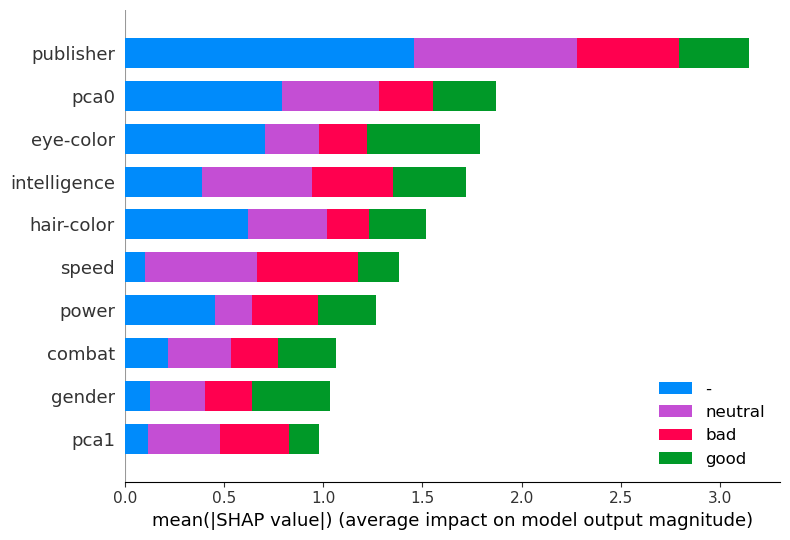

In [20]:
shap.summary_plot(shap_values, X_test, max_display=len(features), class_names=categories_names)

Powyżej widać że najbardziej znaczącą cechą pozwalającą zakwalifikować obserwację jest <u>publisher</u>. Widać że dla nieokreślonej klasy bohaterów ta cecha odgrywa bardzo istotną rolę. Z wykresu można również wyczytać że w przypadku klasyfikacji do <u>good</u> bardzo ważny jest kolor oczu.

Sprawdźmy w takim razie jak wygląda istosność cech dla klasy <u>good</u>. Użyjmy tym razem wykresu <b>beeswarm</b>

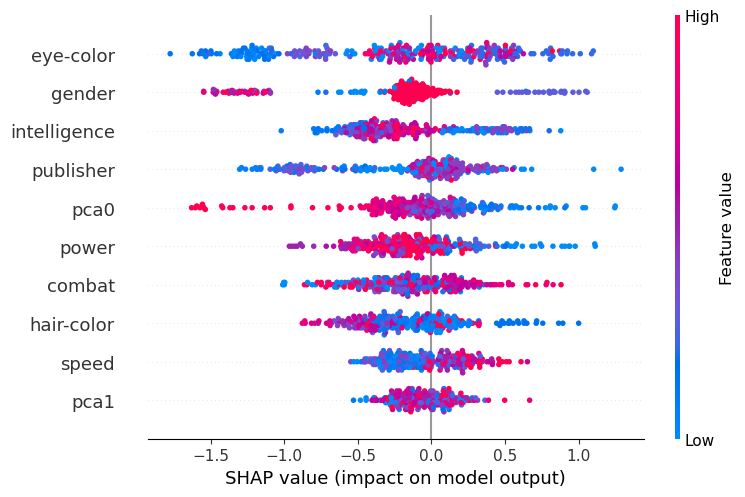

In [21]:
shap.plots.beeswarm(explanation[:,:,categories_names.index('good')], max_display=len(features))

Potwierdziło się że w przypadku przypisania do klasy <u>good</u> najistosniejszą rolę odgrywa kolor oczu. Ponieważ jest to wartość która została zaenkodowana, na wykrresie nie widać zależności czy powinna rosnąć czy maleć. Po prsotu znaczenie mają jej poszczegółne wartości nie to czy maleją czy rosną. Inaczej jest w przypadku <u>pca0</u>, widać tu wyraźnie że im wartośc jest wyższa tym mniejsza szansa że obserwacja zostanie zaklasyfikowana do <u>good</u>

<h2>Analiza wpływu cech na konkretną obserwacje</u>

Spróbujmy się dowiedzieć co wpłyneło na to że dana obserwacja zostałą sklasyfikowana błędnie. Posłóżmy się obserwacją znajdującą się pod indeksem 0 na liście błędnych obserwacji. Najpierw sprawdźmy co wpłynęło na daną predykcję.

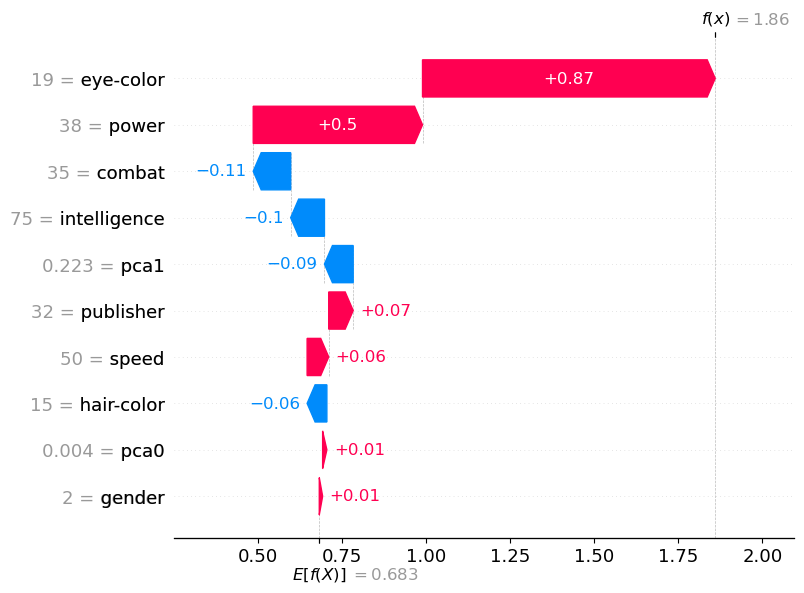

In [22]:

id_to_explain = wrong_prediction_indexes[0].index
output_to_explain = wrong_prediction_indexes[0].predicted
shap.plots.waterfall(explanation[id_to_explain,:,output_to_explain], max_display=len(features))


Na wykresie widać że cechami silnie wzmacniającymi błędny wybór były <u>eye-color</u> oraz <u>power</u>. Od błędnego wyboru model "odciągały" cechy <u>combat</u>, <u>intelligence<u/> oraz <u>pca1</u>. Jednak ich wpływ był dużo mniejszy niż wcześniej wspomniane.

Sprawdźmy teraz jakie cechy przemawiały za prawidłowym wyborem i od niego odwodziły.

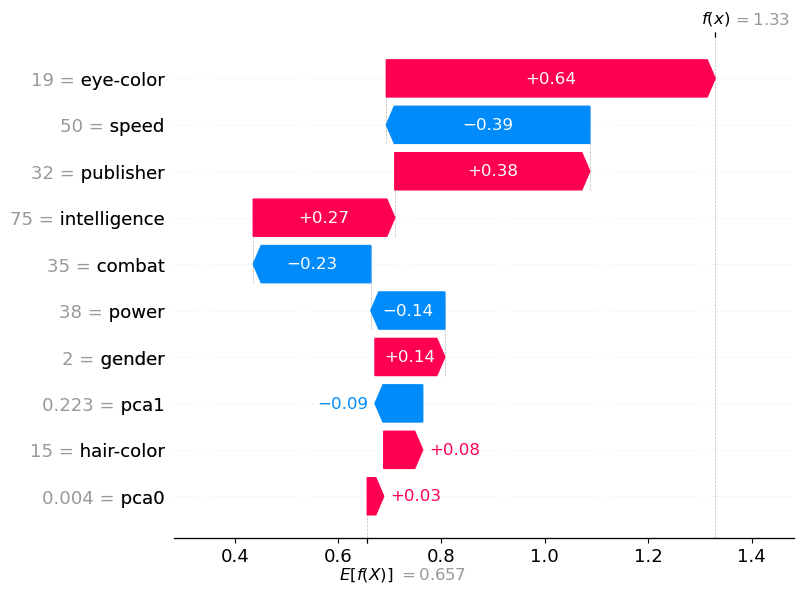

In [23]:
id_to_explain = wrong_prediction_indexes[0].index
output_to_explain = wrong_prediction_indexes[0].expected
shap.plots.waterfall(explanation[id_to_explain,:,output_to_explain])


Widać że za wprawidłowym wyborem przemwiał również <u>eye-color</u> jednak w tym wypadku jego wpływ był dużo słabszy. Od prawidłowego wyboru silnie odwodziła za to <u>speed</u>. Ostateczniw wpłyneło to że próbka została zakwalifikowana niepoprawnie.

Innym ze sposobów prezentacji wpływu cech na klasyfikacje danej próbki jest wykres prezentowany poniżej.

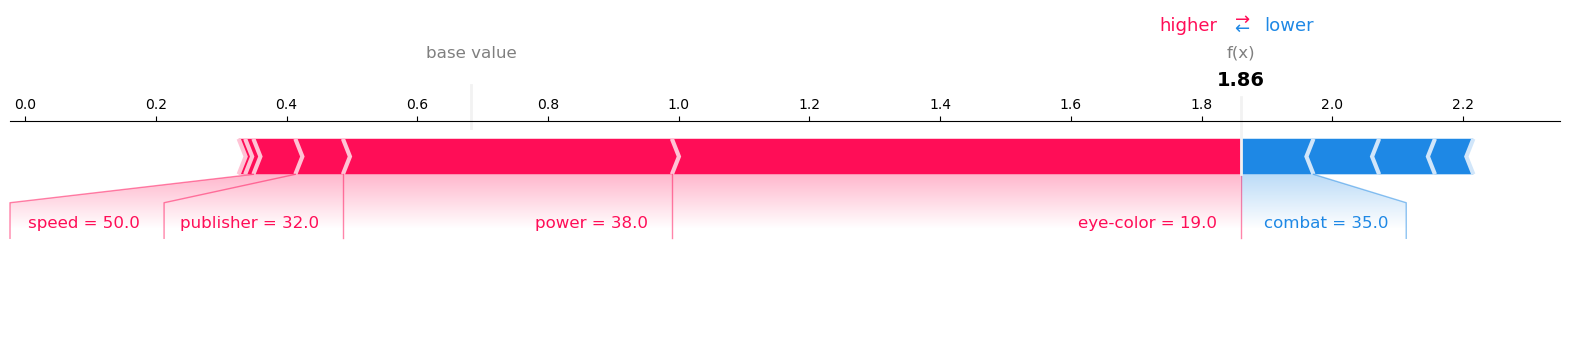

In [46]:
i=wrong_prediction_indexes[0].index
cat = wrong_prediction_indexes[0].predicted

p = shap.force_plot(explainer.expected_value[cat], explanation.values[i,:,cat], X_test.values[i], feature_names=X_train.columns, matplotlib=True, show=False)
plt.savefig(f'force_plot_{i}_{cat}_predicted.png')
p

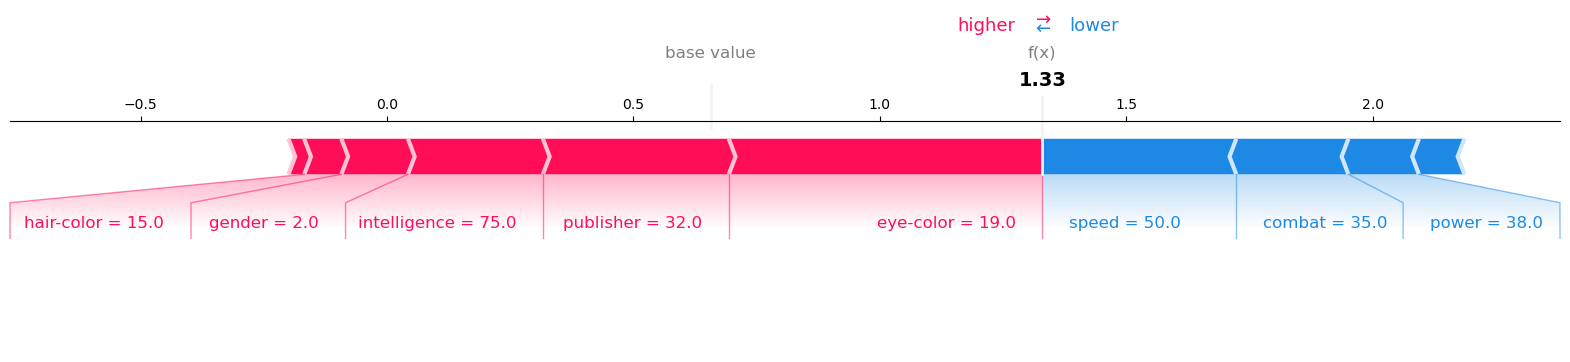

In [47]:
i=wrong_prediction_indexes[0].index
cat = wrong_prediction_indexes[0].expected

p = shap.force_plot(explainer.expected_value[cat], explanation.values[i,:,cat], X_test.values[i], feature_names=X_train.columns, matplotlib=True, show=False)
plt.savefig(f'force_plot_{i}_{cat}_expected.png')
p

Dużo lepiej widać na nim dysproporcje między siłą cech wspierających i osłąbiających klasyfikacje do danej klasy.